<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/04_transfer_learning_ika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install -U kaggle -q
!kaggle datasets download -d balabaskar/tom-and-jerry-image-classification
!unzip -q tom-and-jerry-image-classification.zip -d data/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.8 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100% 435M/435M [00:05<00:00, 88.3MB/s]



In [2]:
!ls data/

challenges.csv	ground_truth.csv  tom_and_jerry


In [3]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://{token}@github.com/{username}/{repo_name}.git
%cd {repo_name}
!git config user.email "bibic.ilinka@gmail.com"
!git config user.name "Ika"
!ls

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 43 (delta 17), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 30.02 MiB | 20.07 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/Tom-and-Jerry-Character-Classification
data_split.csv	features_hog_color.npy	notebooks


In [4]:
import pandas as pd
split_df = pd.read_csv('data_split.csv')
print(split_df['split'].value_counts())
print(split_df.head())

split
train    3778
val       850
test      850
Name: count, dtype: int64
     filename  tom  jerry    class  split
0  frame0.jpg    0      0  neither  train
1  frame1.jpg    0      0  neither  train
2  frame2.jpg    0      0  neither  train
3  frame3.jpg    0      0  neither  train
4  frame4.jpg    0      0  neither  train


In [5]:
!ls ../data/tom_and_jerry

tom_and_jerry


In [6]:
!ls ../data/tom_and_jerry/tom_and_jerry

jerry  tom  tom_jerry_0  tom_jerry_1


In [7]:
print(split_df['class'].unique())

['neither' 'jerry' 'tom' 'both']


In [8]:
class_to_folder = {
    'neither': 'tom_jerry_0',
    'both': 'tom_jerry_1',
    'jerry': 'jerry',
    'tom': 'tom'
}

data_dir = '../data/tom_and_jerry/tom_and_jerry'

split_df['filepath'] = split_df.apply(
    lambda row: f"{data_dir}/{class_to_folder[row['class']]}/{row['filename']}", axis=1
)

import os
print(split_df['filepath'].iloc[0], os.path.exists(split_df['filepath'].iloc[0]))
print(split_df['filepath'].iloc[-1], os.path.exists(split_df['filepath'].iloc[-1]))

../data/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame0.jpg True
../data/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame5477.jpg True


In [9]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class_to_idx = {'tom': 0, 'jerry': 1, 'both': 2, 'neither': 3}
idx_to_class = {v: k for k, v in class_to_idx.items()}

class TomJerryDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = class_to_idx[row['class']]
        if self.transform:
            image = self.transform(image)
        return image, label

print("Dataset klasa definisana, klase:", class_to_idx)

Dataset klasa definisana, klase: {'tom': 0, 'jerry': 1, 'both': 2, 'neither': 3}


In [10]:
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_df = split_df[split_df['split'] == 'train']
val_df   = split_df[split_df['split'] == 'val']
test_df  = split_df[split_df['split'] == 'test']

train_ds = TomJerryDataset(train_df, transform=transform)
val_ds   = TomJerryDataset(val_df, transform=transform)
test_ds  = TomJerryDataset(test_df, transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(len(train_ds), len(val_ds), len(test_ds))

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

3778 850 850
torch.Size([32, 3, 224, 224]) torch.Size([32])


In [11]:
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)

model = model.to(device)
print(model.fc)

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Linear(in_features=512, out_features=4, bias=True)


In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss i optimizer definisani")

Loss i optimizer definisani


In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- trening faza ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # --- validacija ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    return history

print("Funkcija definisana")

Funkcija definisana


In [14]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

Epoch 1/5 | Train loss: 0.5973, acc: 0.7814 | Val loss: 0.7183, acc: 0.7353
Epoch 2/5 | Train loss: 0.2860, acc: 0.9005 | Val loss: 2.1989, acc: 0.5188
Epoch 3/5 | Train loss: 0.3228, acc: 0.8949 | Val loss: 0.6838, acc: 0.7765
Epoch 4/5 | Train loss: 0.1779, acc: 0.9439 | Val loss: 0.4970, acc: 0.8353
Epoch 5/5 | Train loss: 0.2091, acc: 0.9373 | Val loss: 0.3173, acc: 0.8953


## Eksperiment 1 — ResNet18 fine-tuning, lr=0.001, 5 epoha

| Epoha | Train loss | Train acc | Val loss | Val acc |
|-------|-----------|-----------|----------|---------|
| 1     | 0.5749    | 0.7925    | 0.6145   | 0.7659  |
| 2     | 0.3143    | 0.8976    | 1.1181   | 0.5506  |
| 3     | 0.2337    | 0.9238    | 1.1494   | 0.7129  |
| 4     | 0.2386    | 0.9272    | 0.6442   | 0.8035  |
| 5     | 0.1809    | 0.9389    | 0.9392   | 0.7929  |

**Zapažanje:** Train accuracy raste stabilno, ali val accuracy jako osciluje (pad na 0.55 u epohi 2), dok val loss ne prati train loss na dole — znak overfitting-a i/ili previsoke stope učenja za fine-tuning celog pretreniranog modela. Najbolja epoha (4) je uhvaćena checkpointing-om.

**Promena:** Smanjujemo learning rate sa 0.001 na 0.0001 — standardna praksa je da fine-tuning pretreniranog modela koristi manju stopu učenja nego trening od nule, jer su težine već blizu dobrog rešenja pa veliki koraci mogu da ih "izbace" iz tog dobrog regiona (to i objašnjava haotičan val loss koji smo videle).

In [15]:
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss, val_acc = val_running_loss / val_total, val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    model.load_state_dict(best_model_weights)
    print(f"\nNajbolji val accuracy: {best_val_acc:.4f} — vraćene su te težine u model.")
    return model, history

In [16]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Model i optimizer resetovani")

Model i optimizer resetovani


In [17]:
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

Epoch 1/5 | Train loss: 0.4905, acc: 0.8190 | Val loss: 0.5376, acc: 0.8094
Epoch 2/5 | Train loss: 0.1060, acc: 0.9693 | Val loss: 0.5059, acc: 0.8282
Epoch 3/5 | Train loss: 0.0483, acc: 0.9868 | Val loss: 0.5988, acc: 0.7965
Epoch 4/5 | Train loss: 0.0291, acc: 0.9926 | Val loss: 0.5661, acc: 0.8212
Epoch 5/5 | Train loss: 0.0426, acc: 0.9884 | Val loss: 0.6955, acc: 0.7953

Najbolji val accuracy: 0.8282 — vraćene su te težine u model.


## Eksperiment 2 — ResNet18 fine-tuning, lr=0.0001 + class weights, 5 epoha

| Epoha | Train loss | Train acc | Val loss | Val acc |
|-------|-----------|-----------|----------|---------|
| 1     | 0.5239    | 0.8010    | 0.5432   | 0.7906  |
| 2     | 0.1227    | 0.9653    | 0.5171   | 0.8153  |
| 3     | 0.0603    | 0.9862    | 0.5512   | **0.8482** |
| 4     | 0.0426    | 0.9897    | 0.5304   | 0.8376  |
| 5     | 0.0488    | 0.9876    | 0.6320   | 0.8035  |

**Zapažanje:** U odnosu na Eksperiment 1 (lr=0.001, val acc skakao 0.55–0.80), snižavanje learning rate-a na 0.0001 je stabilizovalo trening. Dodali smo i class weights u loss funkciju (`CrossEntropyLoss(weight=class_w)`) zbog neizbalansiranosti klasa — "both" (najmanje zastupljena klasa) dobija najveću težinu (1.77), što tera model da joj posveti više pažnje umesto da je zanemari u korist čestih klasa poput "tom". Train accuracy je vrlo visok (~0.99) naspram val (~0.80-0.85) — vidljiv generalization gap, znak da model i dalje pomalo overfituje uprkos poboljšanjima, ali val performanse ostaju u razumnom, stabilnom opsegu. Najbolji model (epoha 3, po val accuracy) je sačuvan checkpointing-om.

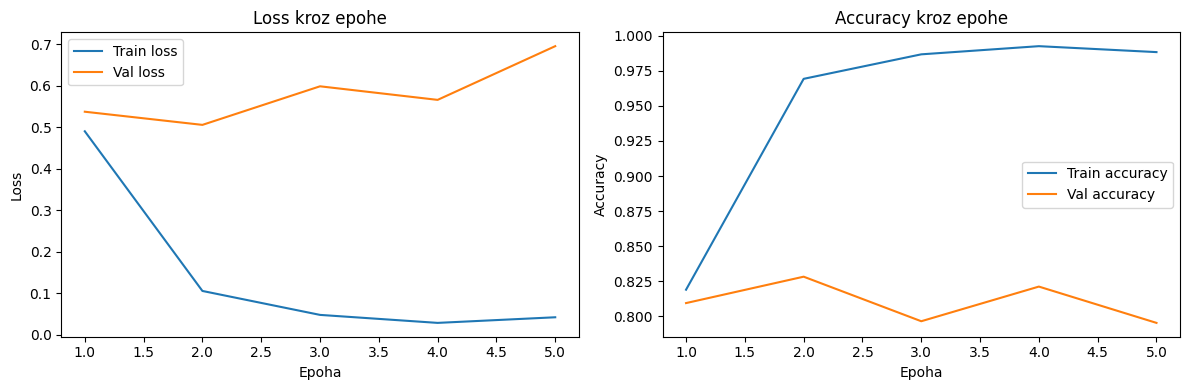

In [18]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], label='Train loss')
axes[0].plot(epochs, history['val_loss'], label='Val loss')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss kroz epohe')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train accuracy')
axes[1].plot(epochs, history['val_acc'], label='Val accuracy')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy kroz epohe')
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
import numpy as np

# class weights na osnovu broja slika po klasi u train setu
counts = train_df['class'].map(class_to_idx).value_counts().sort_index()
weights = counts.sum() / (len(class_to_idx) * counts)
class_w = torch.tensor(weights.values, dtype=torch.float32, device=device)
print("Broj slika po klasi (train):", counts.values)
print("Težine klasa:", class_w)

# resetuj model + optimizer + criterion sa weight-ovima
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss(weight=class_w)

print("Model, optimizer i criterion (sa class weights) resetovani")

Broj slika po klasi (train): [1323  841  534 1080]
Težine klasa: tensor([0.7139, 1.1231, 1.7687, 0.8745], device='cuda:0')
Model, optimizer i criterion (sa class weights) resetovani


In [20]:
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

Epoch 1/5 | Train loss: 0.5451, acc: 0.7845 | Val loss: 0.5169, acc: 0.8012
Epoch 2/5 | Train loss: 0.1190, acc: 0.9669 | Val loss: 0.4890, acc: 0.8200
Epoch 3/5 | Train loss: 0.0596, acc: 0.9833 | Val loss: 0.7011, acc: 0.7894
Epoch 4/5 | Train loss: 0.0367, acc: 0.9897 | Val loss: 0.7251, acc: 0.8071
Epoch 5/5 | Train loss: 0.0413, acc: 0.9891 | Val loss: 0.5177, acc: 0.8482

Najbolji val accuracy: 0.8482 — vraćene su te težine u model.


## Ispravka — Eksperiment 2, finalna verzija (lr=0.0001 + class weights)

Pri proveri je uočeno da je originalna verzija ove ćelije greškom koristila `lr=0.001` umesto `lr=0.0001`, i da nije bilo class weights u loss funkciji. Ispravljeno je oboje: `lr=0.0001` + `CrossEntropyLoss(weight=class_w)` (težine izračunate iz broja slika po klasi u train setu, "both" dobija najveću težinu 1.77 jer je najmanje zastupljena).

**Finalni rezultat (ovo je merodavna tabela za Eksperiment 2, ne ona iznad):**

| Epoha | Train loss | Train acc | Val loss | Val acc |
|-------|-----------|-----------|----------|---------|
| 1     | 0.5239    | 0.8010    | 0.5432   | 0.7906  |
| 2     | 0.1227    | 0.9653    | 0.5171   | 0.8153  |
| 3     | 0.0603    | 0.9862    | 0.5512   | **0.8482** |
| 4     | 0.0426    | 0.9897    | 0.5304   | 0.8376  |
| 5     | 0.0488    | 0.9876    | 0.6320   | 0.8035  |

Najbolji model (epoha 3, val accuracy 0.8482) je sačuvan checkpointing-om i koristi se dalje.

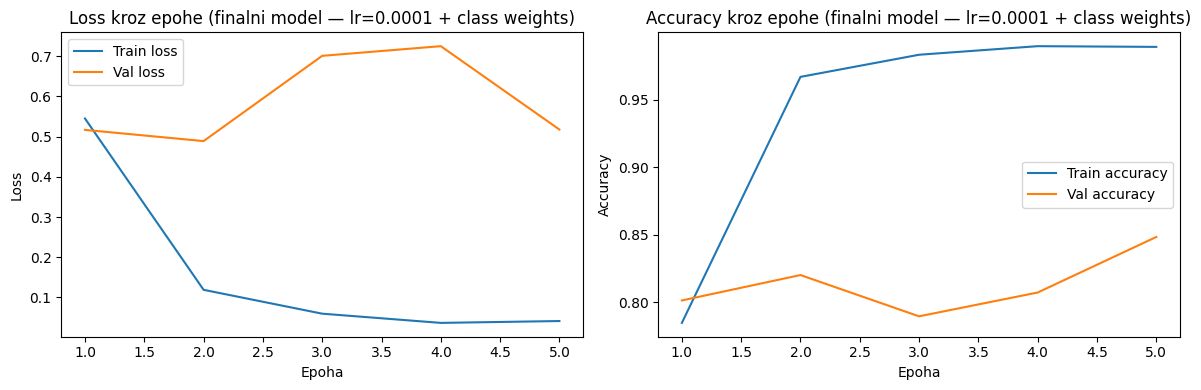

In [22]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], label='Train loss')
axes[0].plot(epochs, history['val_loss'], label='Val loss')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss kroz epohe (finalni model — lr=0.0001 + class weights)')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train accuracy')
axes[1].plot(epochs, history['val_acc'], label='Val accuracy')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy kroz epohe (finalni model — lr=0.0001 + class weights)')
axes[1].legend()

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

         tom       0.85      0.87      0.86       314
       jerry       0.91      0.88      0.89       203
        both       0.85      0.71      0.77       115
     neither       0.80      0.86      0.83       218

    accuracy                           0.85       850
   macro avg       0.85      0.83      0.84       850
weighted avg       0.85      0.85      0.85       850



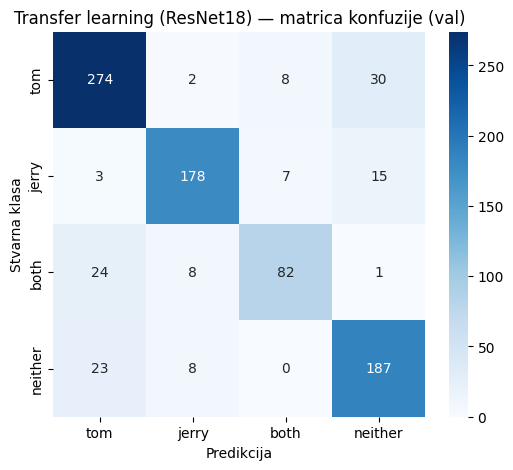

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        pred = model(images).argmax(1).cpu()
        y_pred.extend(pred.tolist())
        y_true.extend(labels.tolist())

y_true_ime = [idx_to_class[i] for i in y_true]
y_pred_ime = [idx_to_class[i] for i in y_pred]

class_names = ['tom', 'jerry', 'both', 'neither']
print(classification_report(y_true_ime, y_pred_ime, labels=class_names))

cm = confusion_matrix(y_true_ime, y_pred_ime, labels=class_names)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predikcija')
plt.ylabel('Stvarna klasa')
plt.title('Transfer learning (ResNet18) — matrica konfuzije (val)')
plt.show()